# Session 4: Convolutional Neural Networks and Filters

This notebook contains structured tasks based on Session 4 materials.

**Instructions:**
- Do NOT use a separate `.py` file. Complete all tasks directly in this notebook.
- Keep your code clear and well-commented.
- For Visulaization, please use `%matplotlib inline`
- Submit your completed notebook by uploading it to your forked repository.

### ***DO NOT UPLOAD THE DATASET TO GITHUB as it's too large***
<hr>

## Task 1: Convolutional Filters on an Image
Apply several 2D filters (Sobel X, Sobel Y, Laplacian, and Sharpen) to an image and visualize the results side by side.

**Hint:**
- Use OpenCV (`cv2.filter2D`) or NumPy to apply kernels.
- Define common kernels (Sobel, Laplacian, Sharpen).
- Use `matplotlib.pyplot` to plot the original and filtered images.

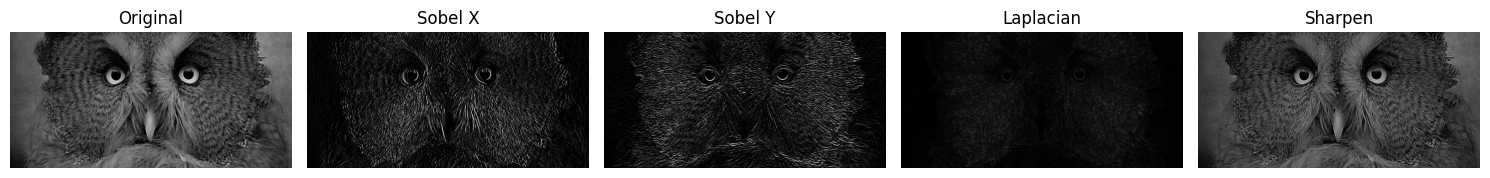

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img = cv2.imread('/content/owel.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Define kernels
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

laplacian = np.array([[0,  1, 0],
                      [1, -4, 1],
                      [0,  1, 0]])

sharpen = np.array([[ 0, -1,  0],
                    [-1,  5, -1],
                    [ 0, -1,  0]])

# Apply filters
filtered_sobel_x = cv2.filter2D(gray, -1, sobel_x)
filtered_sobel_y = cv2.filter2D(gray, -1, sobel_y)
filtered_laplacian = cv2.filter2D(gray, -1, laplacian)
filtered_sharpen = cv2.filter2D(gray, -1, sharpen)

# Plot results
titles = ['Original', 'Sobel X', 'Sobel Y', 'Laplacian', 'Sharpen']
images = [gray, filtered_sobel_x, filtered_sobel_y, filtered_laplacian, filtered_sharpen]

plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()


## Task 2: Build a Simple CNN on FashionMNIST
Construct and train a small Convolutional Neural Network (CNN) on the FashionMNIST dataset.

**Hint:**
- Use `torchvision.datasets.FashionMNIST` for loading data.
- Define a small CNN with `nn.Conv2d`, `nn.ReLU`, `nn.MaxPool2d`, and `nn.Linear`.
- Train for a few epochs using an optimizer (e.g., Adam) and loss function (e.g., CrossEntropyLoss).
- Print training accuracy after each epoch.

In [ ]:
#  Our Basic Libraries
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import FashionMNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

#  Define Transform: Convert image to tensor and normalize to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

#  Load FashionMNIST Dataset
train_data = FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

#  Define a Simple CNN Class
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # Output: 16×28×28
            nn.ReLU(),
            nn.MaxPool2d(2)  # Output: 16×14×14 size by half
        )
        self.fc = nn.Linear(16 * 14 * 14, 10)  # 10 output classes

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        return x

#  Set Up Model, Optimizer, and Loss Function
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#  Training Loop (2–3 Epochs)
for epoch in range(3):
    correct = 0
     total = 0
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accuracy calculation
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}, Accuracy: {accuracy:.2f}%")


100%|██████████| 26.4M/26.4M [00:01<00:00, 19.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 308kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.62MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.9MB/s]


Epoch 1, Accuracy: 84.89%
Epoch 2, Accuracy: 89.23%
Epoch 3, Accuracy: 90.22%


## Task 3: Visualize Feature Maps
Visualize feature maps produced by the first convolutional layer of your CNN.

**Hint:**
- Take a single image from the test set.
- Pass it through the first convolutional layer (`net.conv1`).
- Convert the output to NumPy and plot several channels as images.

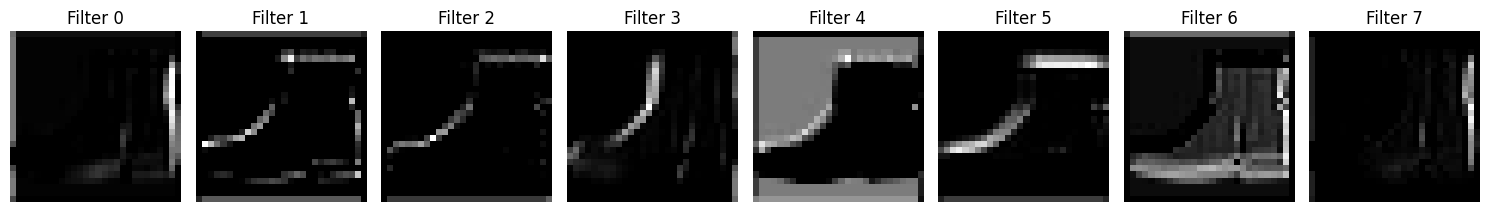

In [ ]:
#  Load Test Data
test_data = FashionMNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=1, shuffle=True)

#  Take One Test Image
dataiter = iter(test_loader)
image, label = next(dataiter)
image = image.to(device)

#  Forward Pass Through First Conv Layer
model.eval()
with torch.no_grad():
    # Access the first convolutional layer and the subsequent ReLU activation
    conv_layer = model.conv[0]
    relu_activation = model.conv[1]
    feature_maps = relu_activation(conv_layer(image))

#  Convert Feature Maps to NumPy
feature_maps_np = feature_maps.cpu().numpy().squeeze()

#  Plot First Few Feature Maps
plt.figure(figsize=(15, 5))
for i in range(8):  # Show first 8 channels
    plt.subplot(1, 8, i+1)
    plt.imshow(feature_maps_np[i], cmap='gray')
    plt.title(f'Filter {i}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Task 4: Haar Cascade Face Detection

Apply Haar Cascade classifiers for basic object detection (faces).

**Hint:**
- Use `cv2.CascadeClassifier` with a pre-trained XML file (e.g., `haarcascade_frontalface_default.xml`).
- Convert the input image to grayscale before detection.
- Use `detectMultiScale` to get bounding boxes.
- Draw rectangles on detected faces with `cv2.rectangle`.
- Visualize with Matplotlib.


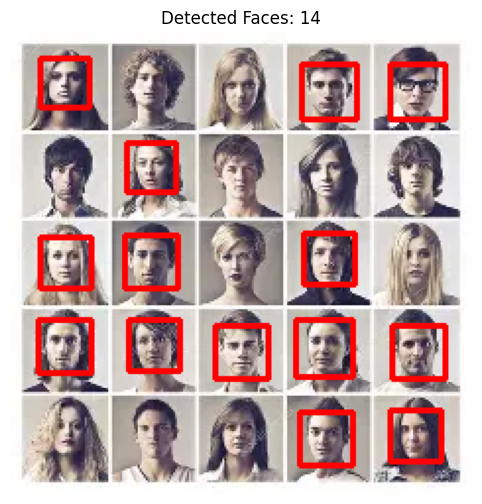

In [ ]:
#  Import Libraries
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

# Load an Image Containing a Face
img = cv2.imread('/content/FACES.webp')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Load Haar Cascade XML (Frontal Face)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

#  Detect Faces
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

# Draw Bounding Boxes on Original Image
for (x, y, w, h) in faces:
    cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (255, 0, 0), 2)

#  Display Result with Matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title(f'Detected Faces: {len(faces)}')
plt.axis('off')
plt.show()